### Analysis of Probability Distribution Priors from ResStock

heating_setpoint: 22.0,

cooling_setpoint: 26.6,

people_per_area: 3.0,

infil_flow_rate_living: 0.01,

infil_flow_rate_garage: 0.05,

infil_flow_rate_attic: 0.05,

watts_equip: 500, Can't find this

watts_lights: 1000, Can't find this

heating_COP: 4.0,

fan_efficiency: 0.7,

pressure_rise: 400.0,

solar_transmittance: 0.837,

burner_eff: 0.8,

vent_flow_rate: 0.131944

Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
from scipy.stats import gaussian_kde, gamma, norm


Configurations

In [2]:
resstock_dir = "/jumbo/keller-lab/Jeremy_Wang/resstock"
housing_characteristics_dir = os.path.join(resstock_dir, "project_national", "housing_characteristics")
options_dir = os.path.join(resstock_dir, "resources", "options_lookup.tsv")

Reading Options File

In [3]:
# Read all lines manually, pad short rows with NaN
with open(options_dir, 'r') as f:
    lines = [line.strip().split('\t') for line in f]

header = lines[0]
max_cols = max(len(row) for row in lines[1:])

# Pad header if it's shorter than some rows
while len(header) < max_cols:
    header.append(f'col_{len(header)}')

# Pad each row with None (becomes NaN in DataFrame)
padded = [row + [None] * (max_cols - len(row)) for row in lines[1:]]

options = pd.DataFrame(padded, columns=header)

List of all TSV Files Available

In [4]:
tsv_files = [f for f in os.listdir(housing_characteristics_dir) if f.endswith('.tsv')]

Function for extracting and cleaning TSV Files

In [5]:
def extract_and_clean (filename):
    df = pd.read_csv(os.path.join(housing_characteristics_dir, filename), sep='\t')

    # removing missing columns
    dep_cols = [c for c in df.columns if c.startswith("Dependency=")]
    filtered = df[
        (~df[dep_cols].eq("Not Available").any(axis=1)) &
        (df[dep_cols].notna().all(axis=1))
    ]
    return filtered


#### Heating setpoint 

In [6]:
# reading heating_setpoint file
heating_setpoint = extract_and_clean("Heating Setpoint.tsv")

# skeleton IDF constraints
climate_zone = "5A" # chicago 
building_type = "Single-Family Detached" 
HVAC_heating_type = "Ducted Heat Pump"

# filter by constraints
mask = (
    (heating_setpoint['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
    (heating_setpoint['Dependency=Geometry Building Type RECS'] == building_type) &
    (heating_setpoint['Dependency=HVAC Heating Type'] == HVAC_heating_type) # &
    # (heating_setpoint['Dependency=HVAC Has Zonal Electric Heating'] == 'No')
    )

heating_filtered = heating_setpoint[mask]

# delete misinputted dataset
heating_filtered = heating_filtered[heating_filtered['Dependency=Tenure'] != 'Not Available']

# Get option columns
opt_cols = [c for c in heating_filtered.columns if c.startswith('Option=')]

# Weight by source_weight
heating_weights = heating_filtered['source_weight'].values
heating_weights = heating_weights / heating_weights.sum()

# Weighted average across tenure types
heating_weighted_probs = pd.Series(
    np.average(heating_filtered[opt_cols].values, axis=0, weights=heating_weights),
    index=opt_cols
)

### convert setpoints from fahrenheit to celsius
# Convert option names from F to C
def f_to_c(f):
    return (f - 32) * 5/9

# Extract numeric F values from option names
heating_f_values = np.array([float(c.replace('Option=', '').replace('F', '')) 
                     for c in opt_cols])

# Convert to Celsius
heating_c_values = f_to_c(heating_f_values)

heating_prior = pd.DataFrame()
heating_prior["Temp"] = heating_c_values
heating_prior["Prob"] = heating_weighted_probs.values

### Using Continuous Distributions to Fit Data

In [7]:
heating_prior.columns[0]

'Temp'

In [87]:
# fits data and for KDE, gamma, and returns fit
def fit_data(prior):
    # load data
    x = prior.iloc[:, 0].values
    w = prior.iloc[:, 1].values
    # normalize weights
    w = w / w.sum()

    ### KDE
    kde = gaussian_kde(x, weights=w)

    # scale KDE to match probability bars
    dx = np.mean(np.diff(np.sort(x)))

    xs_KDE = np.linspace(x.min() - 2*dx, x.max() + 2*dx, 500)
    ys_KDE = kde(xs_KDE)
    ys_KDE_scaled = ys_KDE * dx

    ### Gamma distribution fit
    samples = np.random.choice(x, size=10000, p=w)
    shape, loc_g, scale_g = gamma.fit(samples, floc=0)

    xs_gamma = np.linspace(x.min() - 2*dx, x.max() + 2*dx, 500)
    ys_gamma = gamma.pdf(xs_gamma, shape, loc=loc_g, scale=scale_g)
    ys_gamma_scaled = ys_gamma * dx

    ### Plotting

    plt.figure(figsize=(8, 5))

    # discrete probabilities
    plt.bar(
        x,
        w,
        width=dx/3,
        alpha=0.4,
        label="Discrete probabilities"
    )

    # KDE
    # plt.plot(xs_KDE, ys_KDE_scaled, linewidth=2, label="Weighted KDE")

    # Gamma fit
    plt.plot(xs_gamma, ys_gamma_scaled, linewidth=2, label="Gamma fit")

    # # KDE
    # plt.plot(xs_KDE, ys_KDE, linewidth=2, label="Weighted KDE")

    # # Gamma fit
    # plt.plot(xs_gamma, ys_gamma, linewidth=2, label="Gamma fit")

    plt.xlabel(prior.columns[0])
    plt.ylabel("Density / Probability")
    plt.title("Distribution Fit Comparison")
    plt.legend()
    plt.show()

    return shape, loc_g, scale_g



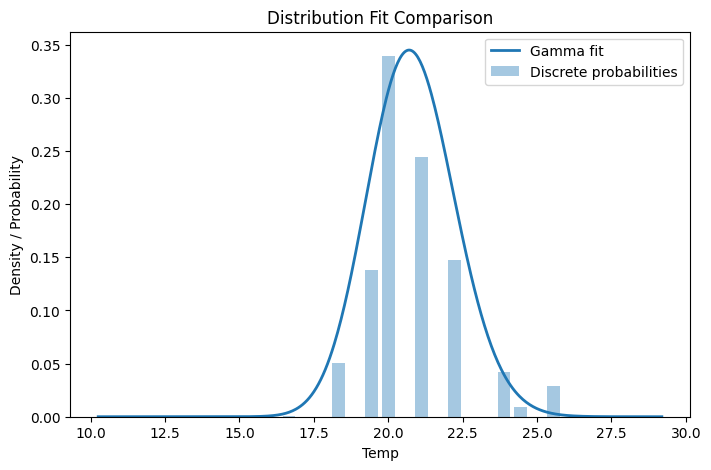

In [ ]:
# extract key params used for inverse CDF transformation onto the gamma fit
heating_shape, heating_loc_g, heating_scale_g = fit_data(heating_prior)

### Cooling Setpoint

In [19]:
# reading cooling_setpoint file
cooling_setpoint = extract_and_clean("Cooling Setpoint.tsv")

# skeleton IDF constraints
climate_zone = "5A" # chicago 
building_type = "Single-Family Detached" 
HVAC_cooling_type = "Ducted Heat Pump"

# filter by constraints
mask = (
    (cooling_setpoint['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
    (cooling_setpoint['Dependency=Geometry Building Type RECS'] == building_type) &
    (cooling_setpoint['Dependency=HVAC Cooling Type'] == HVAC_cooling_type)
    )
cooling_filtered = cooling_setpoint[mask]
cooling_filtered = cooling_filtered[cooling_filtered['Dependency=Tenure'] != 'Not Available']
cooling_filtered = cooling_filtered.drop(columns=['Option=Void'], errors='ignore')

# Get option columns
opt_cols = [c for c in cooling_filtered.columns if c.startswith('Option=')]

# Weight by source_weight
cooling_weights = cooling_filtered['source_weight'].values
cooling_weights = cooling_weights / cooling_weights.sum()
# Weighted average across tenure types
cooling_weighted_probs = pd.Series(
    np.average(cooling_filtered[opt_cols].values, axis=0, weights=cooling_weights),
    index=opt_cols
)

### convert setpoints from fahrenheit to celsius
# Convert option names from F to C
def f_to_c(f):
    return (f - 32) * 5/9

# Extract numeric F values from option names
cooling_f_values = np.array([float(c.replace('Option=', '').replace('F', '')) 
                     for c in opt_cols])

# Convert to Celsius
cooling_c_values = f_to_c(cooling_f_values)

cooling_prior = pd.DataFrame()
cooling_prior["Temp"] = cooling_c_values
cooling_prior["Prob"] = cooling_weighted_probs.values

### Gap

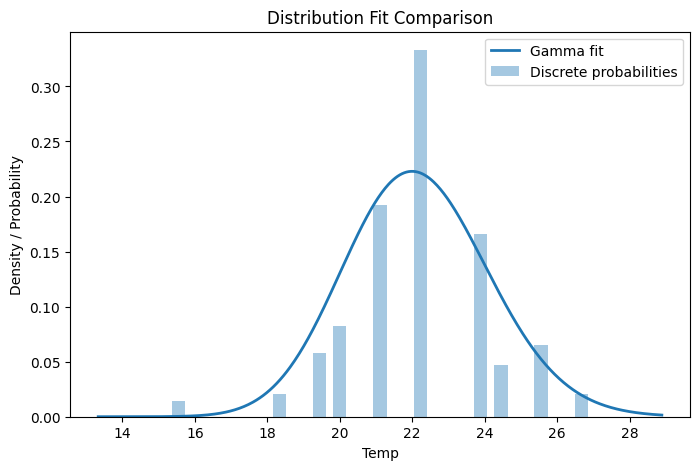

In [35]:
sd_frac = 0.05

# extract key params used for inverse CDF transformation onto the gamma fit
cooling_shape, cooling_loc_g, cooling_scale_g = fit_data(cooling_prior)

# extracting "mean" and "std" from the gamma distribution
heating_mean = heating_shape * heating_scale_g + heating_loc_g
cooling_mean = cooling_shape * cooling_scale_g + cooling_loc_g

# multiply by the standard fraction 
gap_mean = cooling_mean - heating_mean
gap_std = gap_mean * sd_frac

Plot of Heating and Cooling PDFs

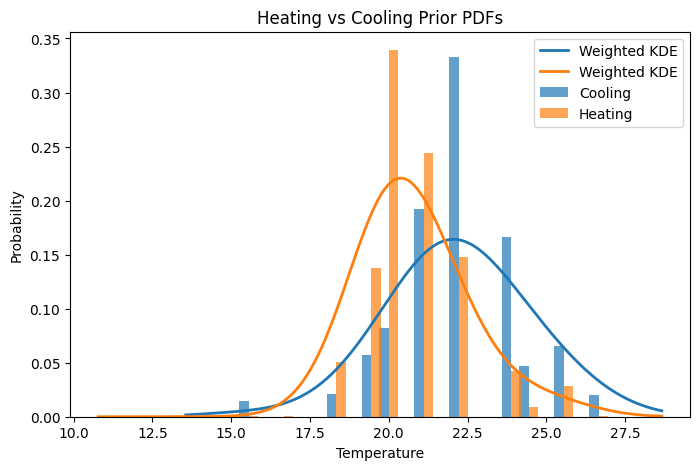

In [20]:
width = 0.3  # bar width

plt.figure(figsize=(8,5))

# Cooling
plt.bar(
    cooling_prior['Temp'] - width/2,
    cooling_prior['Prob'],
    width=width,
    label='Cooling',
    alpha=0.7
)

# KDE curve on top
plt.plot(
    xs_cooling,
    ys_cooling,
    linewidth=2,
    label='Weighted KDE'
)

# Heating
plt.bar(
    heating_prior['Temp'] + width/2,
    heating_prior['Prob'],
    width=width,
    label='Heating',
    alpha=0.7
)

plt.plot(
    xs_heating,
    ys_heating,
    linewidth=2,
    label='Weighted KDE'
)

plt.xlabel("Temperature")
plt.ylabel("Probability")
plt.title("Heating vs Cooling Prior PDFs")
plt.legend()

plt.show()

#### People

In [38]:
# reading file
people_filtered = extract_and_clean("Occupants.tsv")

# IDF constraints
building_type = "Single-Family Detached" 
census_division = "East North Central"
bedrooms = "3" # assume 3 bedrooms because IDF specifies that number of occupants

# Note: Not controlling for income, metro status, or tenure status

# mask
mask = (
    (people_filtered['Dependency=Geometry Building Type RECS'] == building_type) &
    (people_filtered['Dependency=Census Division'] == census_division) & 
    (people_filtered['Dependency=Bedrooms'] == bedrooms)
)

people_filtered = people_filtered[mask]

# Get option columns
opt_cols = [c for c in people_filtered.columns if c.startswith('Option=')]

# Weight by source_weight
people_weights = people_filtered['source_weight'].values
people_weights = people_weights / people_weights.sum()

# Weighted average across dependency types
people_weighted_probs = pd.Series(
    np.average(people_filtered[opt_cols].values, axis=0, weights=people_weights),
    index=opt_cols
)

people_values = np.array([
    float(c.replace("Option=", "").replace("+", ""))  # remove 'Option=' and '+'
    for c in opt_cols
])

people_prior = pd.DataFrame()
people_prior["People"] = people_values
people_prior["Prob"] = people_weighted_probs.values

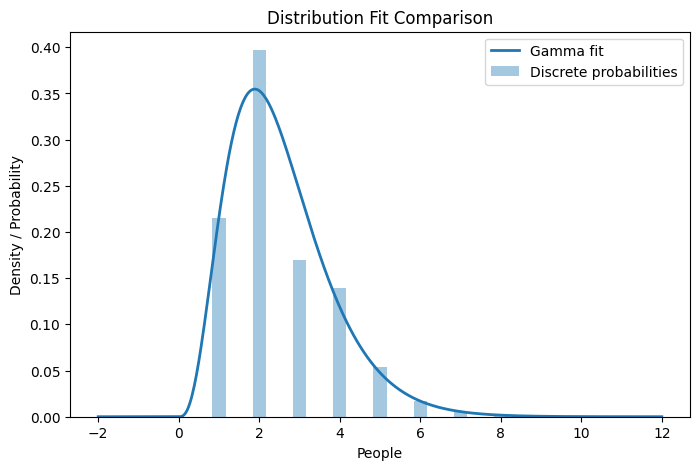

In [39]:
people_shape, people_loc_g, people_scale_g = fit_data(people_prior)

#### Infiltration Rate

Assumptions:
Living Zone, Garage Zone, Attic Zone all use the same infiltration rate

CC (Conversion Coefficient) between ACH50 to ACH = 22.2

Floor Area = 186 m^2

Height = 3 m

In [40]:
infil_filtered = extract_and_clean("Infiltration.tsv")

# IDF Constraints
climate_zone = "5A" # Chicago  
floor_area = ["1500-1999","2000-2499"] # consider floor areas ranging from 1500 - 2499 ft^2

mask = (
    (infil_filtered['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
    ((infil_filtered['Dependency=Geometry Floor Area'] == floor_area[0]) | (infil_filtered['Dependency=Geometry Floor Area'] == floor_area[1]))
)

infil_filtered = infil_filtered[mask]

opt_cols = [c for c in infil_filtered.columns if c.startswith("Option=")]

# weight by sampling probability
infil_probs = pd.Series(
    np.average(
        infil_filtered[opt_cols].values,
        axis=0,
        weights=infil_filtered["sampling_probability"]
    ),
    index=opt_cols
)

# unit conversations 
CC = 22.2 # conversion coefficient
FA = 186 # Floor Area m^2
H = 3 # Height  m 

ACH50_values = np.array([float(c.replace('Option=', '').replace('ACH50', '')) 
                     for c in opt_cols])

Q_values = (ACH50_values * (FA * H))/(3600*CC) # converting into m^3/s

infil_prior = pd.DataFrame()
infil_prior["Q"] = Q_values
infil_prior["Prob"] = infil_probs.values


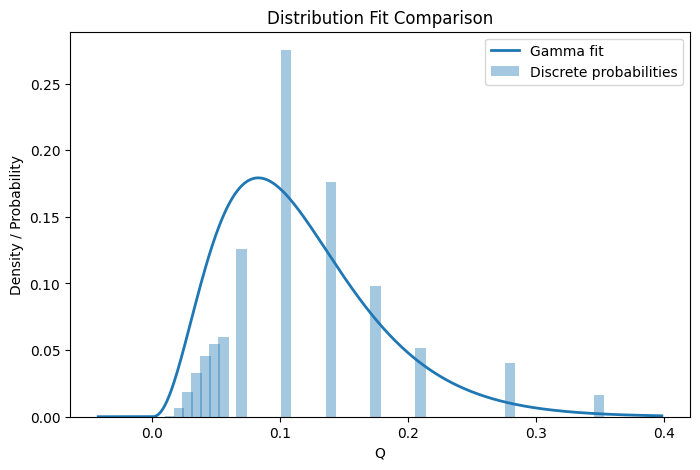

In [41]:
infil_shape, infil_loc_g, infil_scale_g = fit_data(infil_prior)

#### Equipment Watts

Can't find baseline value, and distribution is a singular point

In [43]:
# use TSV file titled "plug loads"
equip_filtered = extract_and_clean("Plug Loads.tsv")
# IDF constraints
census_division = "East North Central"
building_type = "Single-Family Detached"

mask = (
    (equip_filtered['Dependency=Census Division RECS'] == census_division) &
    (equip_filtered['Dependency=Geometry Building Type RECS'] == building_type)
)

equip_filtered = equip_filtered[mask]

#### Lighting Watts

Options are quantitatively describing the type of lights being used

Need Lookup table

In [54]:
lighting = extract_and_clean("Lighting.tsv")

# constraints
state = "IL"
building_type = "Single-Family Detached"

mask = (
    (lighting['Dependency=State'] == state) & 
    (lighting['Dependency=Geometry Building Type RECS'] == building_type)
)

lighting = lighting[mask]

# Get option columns
opt_cols = [c for c in lighting.columns if c.startswith('Option=')]

# Weight by source_weight
lighting_weights = lighting['source_weight'].values
lighting_weights = lighting_weights / lighting_weights.sum()

# Weighted average across dependency types
lighting_weighted_probs = pd.Series(
    np.average(lighting[opt_cols].values, axis=0, weights=lighting_weights),
    index=opt_cols
)


In [55]:
# calculating kwh/yr for interior lighting (assume this encapsulates all lighting energy use)
# Use the same equation for interior as attic and garage

# constants
ffa = 2000 # floor area in ft^2
l_hw = 0.8*(ffa*0.542+334) # interior plug in lighting, kwh/yr
er_cfl = 0.27 # efficiency rating of CFL
er_led = 0.3 # efficiency rating of LED
er_lf = 0.17 # efficiency rating of linear fluorescent
f_lf = 0 # fraction of linear fluorescent lighting, which we will assume is 0 for simplicity

# calculate kwh/yr for each lighting type
def calculate_lighting_kwh(f_inc, f_cfl, f_led):
    SAF = 1.1*f_inc**4 - 1.9*f_inc**3 + 1.5*f_inc**2 - 0.7*f_inc + 1 # smart replacement algorithm factor

    lighting_kwh_yr = l_hw * (((f_inc+0.34)+(f_cfl-0.21)*er_cfl + f_led*er_led + (f_lf-0.13)*er_lf)*SAF*0.9 + 0.1)
    # hours of usage per day
    hours_per_day = 2.7 
    lighting_watts = lighting_kwh_yr * 1000 / (365*hours_per_day) # convert to watts

    return lighting_watts

lighting_inc = calculate_lighting_kwh(f_inc = 1, f_cfl = 0, f_led = 0)
lighting_cfl = calculate_lighting_kwh(f_inc = 0, f_cfl = 1, f_led = 0)
lighting_led = calculate_lighting_kwh(f_inc = 0, f_cfl = 0, f_led = 1)

In [56]:
lighting_lookup = {
    "Option=100% Incandescent": lighting_inc,
    "Option=100% CFL": lighting_cfl,
    "Option=100% LED": lighting_led
}

lighting_weighted_probs = lighting_weighted_probs.reset_index()
lighting_weighted_probs.columns = ["lighting_option", "probability"]

lighting_weighted_probs["watts"] = (
    lighting_weighted_probs["lighting_option"]
    .map(lighting_lookup)
)

In [ ]:
from scipy.interpolate import interp1d

# creating mixed normal distributions for each lighting option, then summing them together according to their probabilities to get a final distribution, which we can then sample from using the inverse CDF method
sd_frac = 0.05

weights = lighting_weighted_probs["probability"].values
means = lighting_weighted_probs["watts"].values

weights = weights / weights.sum()



stds = sd_frac * means

x_grid = np.linspace(0, 2500, 10000)

cdf = np.zeros_like(x_grid)
lighting_pdf = np.zeros_like(x_grid)

for w, mu, sd in zip(weights, means, stds):
    cdf += w * norm.cdf(x_grid, loc=mu, scale=sd)
    lighting_pdf += w * norm.pdf(x_grid, mu, sd)
inv_cdf_lighting = interp1d(
    cdf,
    x_grid,
    bounds_error=False,
    fill_value=(x_grid[0], x_grid[-1])
)

u = np.random.rand(10000)
lighting_samples = inv_cdf_lighting(u)

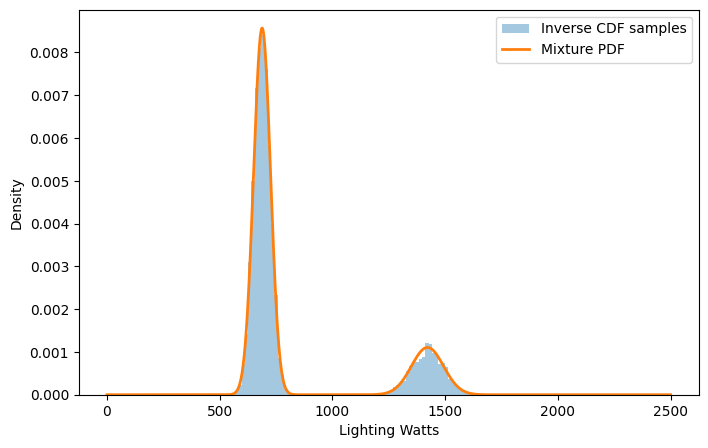

In [ ]:
# Plotting to confirm
plt.figure(figsize=(8,5))

# histogram of generated samples
plt.hist(
    lighting_samples,
    bins=80,
    density=True,
    alpha=0.4,
    label='Inverse CDF samples'
)

# theoretical mixture pdf
plt.plot(
    x_grid,
    lighting_pdf,
    lw=2,
    label='Mixture PDF'
)

# original discrete points
# plt.scatter(
#     means,
#     weights,
#     s=100,
#     color='red',
#     zorder=5,
#     label='Original categories'
# )

plt.xlabel("Lighting Watts")
plt.ylabel("Density")
plt.legend()
plt.show()

In [57]:
lighting_weighted_probs

,lighting_option,probability,watts
0,Option=100% CFL,0.226580,665.422579
1,Option=100% Incandescent,0.196812,1421.689246
2,Option=100% LED,0.576608,696.502031


#### Heating COP

No values can be found with the given dependencies

In [17]:
heating_COP_filtered = extract_and_clean("HVAC Heating Efficiency.tsv")

# IDF Constraints
State = "Others"
heating_fuel = "Electricity"
HVAC_heating_type = "Ducted Heat Pump"


mask = (
    (heating_COP_filtered['Dependency=Custom State'] == State) &
    (heating_COP_filtered['Dependency=Heating Fuel'] == heating_fuel) & 
    (heating_COP_filtered['Dependency=HVAC Heating Type'] == HVAC_heating_type) # & 
    # (burner_filtered['Dependency=HVAC Has Shared System'] == "Heating and Cooling")
)

heating_COP_filtered = heating_COP_filtered[mask]


#### Fan Efficiency

Unable to be sourced

#### Pressure Rise

Not found

#### Solar Transmittance

Options are quantitatively describing the type of window used

Need lookup table

In [68]:
solar_transmittance = extract_and_clean("Windows.tsv")

# constraints
climate_zone = "5A"
building_type = "Single-Family Detached"

mask = (
    (solar_transmittance['Dependency=ASHRAE IECC Climate Zone 2004'] == climate_zone) &
    (solar_transmittance['Dependency=Geometry Building Type RECS'] == building_type)  # & 
    # (burner_filtered['Dependency=HVAC Has Shared System'] == "Heating and Cooling")
)

solar_transmittance = solar_transmittance[mask]
solar_transmittance = solar_transmittance.drop(columns=['Option=Void'], errors='ignore')

# Get option columns
opt_cols = [c for c in solar_transmittance.columns if c.startswith('Option=')]

# Weight by source_weight
solar_weights = solar_transmittance['source_weight'].values
solar_weights = solar_weights / solar_weights.sum()

# Weighted average across dependency types
solar_weighted_probs = pd.Series(
    np.average(solar_transmittance[opt_cols].values, axis=0, weights=solar_weights),
    index=opt_cols
)

In [69]:
# inputting lookup table

windows_df = pd.DataFrame({
    "window_option": solar_weighted_probs.index,

    "SHGC": [
        0.67,
        0.60,
        0.56,
        0.50,
        0.52,
        0.75,
        0.68,
        0.64,
        0.58,
        0.31
    ],

    "window_type": [
        "double",
        "double",
        "double",
        "double",
        "double",
        "single",
        "single",
        "single",
        "single",
        "triple"  
    ]
})


In [70]:
# Conversions from SHGC to solar transmittance
def shgc_to_solar_transmittance(shgc, window_type):
    # Single-pane / high-U equation
    if window_type == "single":

        if shgc < 0.7206:
            ts = (
                0.939998 * shgc**2
                + 0.20332 * shgc
            )
        else:
            ts = (
                1.30415 * shgc
                - 0.30515
            )

    # Double-pane or better equation
    else:
        if shgc <= 0.15:
            ts = 0.41040 * shgc
        else:
            ts = (
                0.085775 * shgc**2
                + 0.963954 * shgc
                - 0.084958
            )
    return ts

windows_df["solar_transmittance"] = windows_df.apply(
    lambda row: shgc_to_solar_transmittance(
        row["SHGC"],
        row["window_type"]
    ),
    axis=1
)

In [71]:
# Add solar transmittance lookup table
solar_lookup = dict(
    zip(
        windows_df["window_option"],
        windows_df["solar_transmittance"]
    )
)

# Convert weighted probabilities Series into DataFrame
solar_weighted_probs = solar_weighted_probs.reset_index()
solar_weighted_probs.columns = [
    "window_option",
    "probability"
]

# Add solar transmittance column
solar_weighted_probs["solar_transmittance"] = (
    solar_weighted_probs["window_option"]
    .map(solar_lookup)
)

### Gamma fit on Solar Transmittance

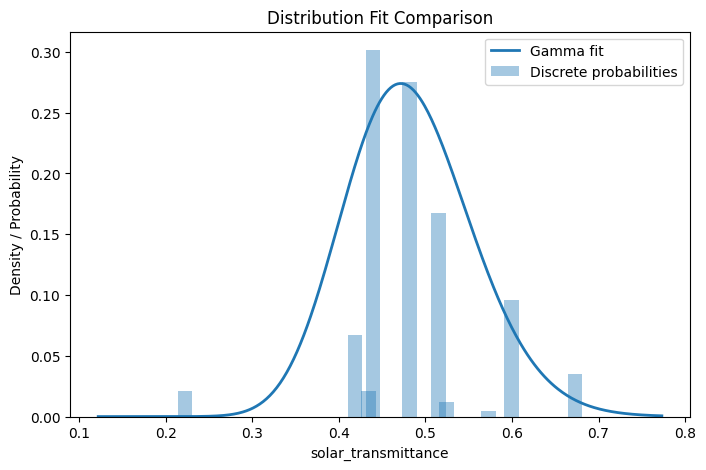

(42.90556565958533, 0, 0.011248130810553314)

In [ ]:
solar_shape, solar_loc_g, solar_scale_g = fit_data(solar_weighted_probs[["solar_transmittance", "probability"]])


#### Burner Efficiency

No values can be found with the given dependencies

In [20]:
burner_filtered = extract_and_clean("HVAC Heating Efficiency.tsv")

# IDF Constraints
State = "Others"
heating_fuel = "Natural Gas"
HVAC_heating_type = "Ducted Heat Pump"


mask = (
    (burner_filtered['Dependency=Custom State'] == State) &
    (burner_filtered['Dependency=Heating Fuel'] == heating_fuel) & 
    (burner_filtered['Dependency=HVAC Heating Type'] == HVAC_heating_type) # & 
    # (burner_filtered['Dependency=HVAC Has Shared System'] == "Heating and Cooling")
)

burner_filtered = burner_filtered[mask]

# Issue arises with no distribution available


In [21]:
burner_filtered

,Dependency=Custom State,Dependency=Heating Fuel,Dependency=HVAC Has Shared System,Dependency=HVAC Heating Type,Dependency=Vintage,"Option=ASHP, SEER2 9.5, 5.8 HSPF2","Option=ASHP, SEER2 12.4, 6.6 HSPF2","Option=ASHP, SEER2 14.3, 7.4 HSPF2","Option=Electric Baseboard, 100% Efficiency","Option=Electric Boiler, 100% AFUE",...,"Option=Fuel Wall/Floor Furnace, 60% AFUE","Option=Fuel Wall/Floor Furnace, 68% AFUE","Option=MSHP, SEER2 13.7, 7.4 HSPF2","Option=MSHP, SEER2 29, 12.3 HSPF2",Option=None,Option=Shared Heating,Option=Void,source_count,source_weight,sampling_probability
360,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1940s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
361,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1950s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
362,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1960s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
363,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1970s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
364,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1980s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
365,Others,Natural Gas,Cooling Only,Ducted Heat Pump,1990s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
366,Others,Natural Gas,Cooling Only,Ducted Heat Pump,2000s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
367,Others,Natural Gas,Cooling Only,Ducted Heat Pump,2010s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
368,Others,Natural Gas,Cooling Only,Ducted Heat Pump,<1940,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
369,Others,Natural Gas,Heating Only,Ducted Heat Pump,1940s,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### Ventilation Flow Rate

Can't find parameter values

### plots

Weighted mean: 20.80C
Weighted std:  1.52C


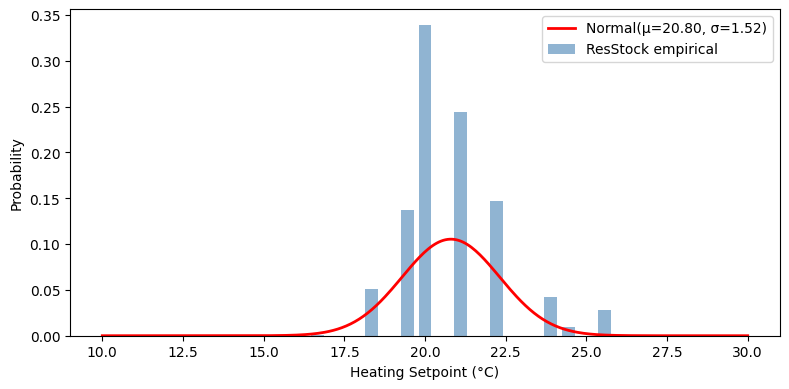


Concrete prior: Normal(mean=20.80, std=1.52)
Weighted mean: 22.18C
Weighted std:  1.97C


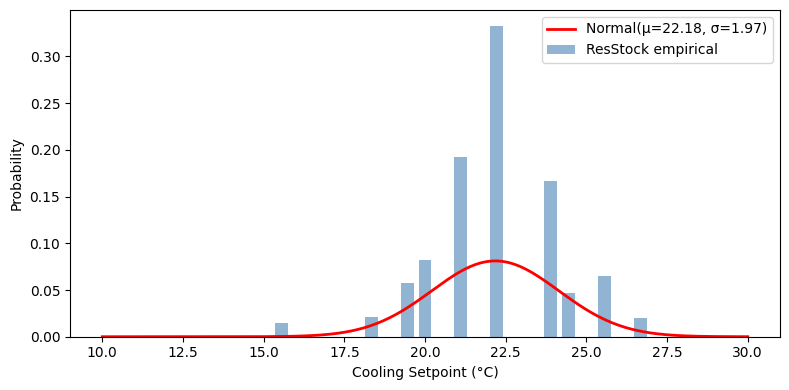


Concrete prior: Normal(mean=22.18, std=1.97)


In [22]:

# Compute weighted mean and std directly from the distribution
def plot_setpoint_prior (c_values, weighted_probs, title):
        mean_c = np.average(c_values, weights=weighted_probs.values)
        std_c = np.sqrt(np.average((c_values - mean_c)**2, weights=weighted_probs.values))

        print(f"Weighted mean: {mean_c:.2f}C")
        print(f"Weighted std:  {std_c:.2f}C")

        x = np.linspace(10, 30, 300)
        normal_pdf = stats.norm.pdf(x, loc=mean_c, scale=std_c)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(c_values, weighted_probs.values, width=0.4, alpha=0.6,
        label='ResStock empirical', color='steelblue')
        ax.plot(x, normal_pdf * 0.4, 'r-', lw=2,
                label=f'Normal(μ={mean_c:.2f}, σ={std_c:.2f})')
        ax.set_xlabel(f'{title} (°C)')
        ax.set_ylabel('Probability')
        ax.legend()
        plt.tight_layout()
        plt.show()

        print(f"\nConcrete prior: Normal(mean={mean_c:.2f}, std={std_c:.2f})")

plot_setpoint_prior(heating_c_values, heating_weighted_probs, "Heating Setpoint")
plot_setpoint_prior(cooling_c_values, cooling_weighted_probs, "Cooling Setpoint")